## Brique generation — mini RAG complet (Ollama, local)

Deuxieme brique du mini RAG, apres `retrieval.ipynb`. Ici on branche un LLM **local**
(Ollama, deja utilise dans `04_exploration/test_llm_iconographie_ollama.ipynb`) sur le
top-k retourne par la recherche vectorielle, pour qu'il redige une reponse plutot que
de se contenter de la liste de voisins.

**Pourquoi Ollama et pas une API payante** : pas de cle/abonnement API necessaire, tout
tourne en local avec les modeles deja telecharges.

**Pourquoi ca devrait mieux marcher que le test precedent** : le bilan de
`test_llm_iconographie_ollama.ipynb` concluait que les modeles locaux (llava, llama3.2)
etaient inutilisables pour l'iconographie ovidienne — mais ce test les interrogeait **a
froid** : reconnaitre un theme depuis les pixels seuls, ou le decrire de memoire, sans
aucune base de reference. Ici le LLM n'a plus a *percevoir* ou *se souvenir* — la
recherche vectorielle a deja fait ce travail et fournit le theme, le score de similarite
et les metadonnees d'edition en texte. Le LLM n'a plus qu'a **synthetiser des faits deja
recuperes**, une tache nettement plus facile pour un petit modele local.

### 1. Reprise du retrieval (voir `retrieval.ipynb` pour le detail des choix)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

RACINE = Path("../../").resolve()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


In [2]:
DOSSIER_VECTOR_DB = RACINE / "data" / "vector_bases"

base_bibles = pd.read_pickle(DOSSIER_VECTOR_DB / "bibles_siglip.pkl")
base_bibles["source"] = "bible"

base_ovide = pd.read_pickle(DOSSIER_VECTOR_DB / "ovide_corpus_complet_siglip.pkl")
base_ovide["source"] = "ovide"

# ovide_corpus_complet_siglip.pkl (2191 illustrations, 28 editions, metadonnees
# Synthese de BNU_corpus.ods) remplace ovide_bnu_corpus_siglip.pkl (73) : memes
# 73 themes connus conserves, ~2100 de plus sans theme individuel mais avec
# metadonnees d'edition (dont type_iconographique / famille_iconographique,
# absentes de l'ancienne base).
COLS_COMMUNES = ["chemin", "source", "theme", "embedding", "embedding_metadonnees",
                  "url_page", "url_image"]
COLS_OVIDE_EXTRA = ["titre", "ville", "annee", "graveur", "technique",
                     "type_iconographique", "famille_iconographique",
                     "theme_precis", "description_planche"]

base_bibles = base_bibles.reindex(columns=COLS_COMMUNES + COLS_OVIDE_EXTRA)
base_ovide = base_ovide.reindex(columns=COLS_COMMUNES + COLS_OVIDE_EXTRA)

index = pd.concat([base_bibles, base_ovide], ignore_index=True)
X_index = np.array(index["embedding"].tolist())
X_index_meta = np.array(index["embedding_metadonnees"].tolist())

print(f"Index unifie : {len(index)} illustrations "
      f"({(index['source'] == 'bible').sum()} Bibles, {(index['source'] == 'ovide').sum()} Ovide), "
      f"embeddings {X_index.shape}")

from sentence_transformers import SentenceTransformer

modele_e5 = SentenceTransformer("intfloat/multilingual-e5-small")
print("Modele e5 charge")

Index unifie : 2661 illustrations (470 Bibles, 2191 Ovide), embeddings (2661, 768)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modele e5 charge


### 1bis. Modele texte-texte pour les metadonnees (e5)

SigLIP n'est entraine qu'a comparer image<->texte, pas texte<->texte : reutiliser SigLIP pour indexer les metadonnees donne de mauvais resultats (verifie empiriquement). `multilingual-e5-small` est concu pour ca.

In [3]:
from transformers import AutoProcessor, AutoModel

NOM_MODELE_SIGLIP = "google/siglip-base-patch16-224"
processor = AutoProcessor.from_pretrained(NOM_MODELE_SIGLIP)
model_siglip = AutoModel.from_pretrained(NOM_MODELE_SIGLIP).to(DEVICE).eval()
print("SigLIP complet (texte + image) charge")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP complet (texte + image) charge


In [4]:
def embed_texte(requete):
    """Encode une requete texte dans le meme espace que les embeddings image de l'index."""
    inputs = processor(text=[requete], padding="max_length", return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        vec = model_siglip.get_text_features(**inputs).pooler_output
    return vec.cpu().numpy()[0]


def embed_image(chemin_ou_image):
    """Encode une image requete (meme pretraitement niveaux de gris que pour l'index)."""
    img = chemin_ou_image if isinstance(chemin_ou_image, Image.Image) else Image.open(chemin_ou_image)
    img = img.convert("RGB").convert("L").convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        vec = model_siglip.get_image_features(**inputs).pooler_output
    return vec.cpu().numpy()[0]


def rechercher(vecteur_requete, k=5, source=None):
    """Top-k illustrations de l'index les plus proches (cosinus) d'un vecteur requete."""
    sous_index = index if source is None else index[index["source"] == source]
    X = X_index if source is None else X_index[sous_index.index.to_numpy()]
    sims = cosine_similarity(vecteur_requete.reshape(1, -1), X)[0]
    ordre = sims.argsort()[::-1][:k]
    resultats = sous_index.iloc[ordre].copy()
    resultats["similarite"] = sims[ordre]
    return resultats.reset_index(drop=True)

### Recherche hybride (visuel + metadonnees)

In [5]:
# colonnes de faits exacts (ville/graveur/technique) : la similarite semantique
# seule confond des mots proches (ex. "Lyon" faisait remonter "Hippomene en
# Lion") — un mot de la requete qui matche mot-pour-mot une valeur de ces
# colonnes est un signal beaucoup plus fort qu'une similarite d'embedding.
COLONNES_FILTRABLES = ["ville", "graveur", "technique"]


def _normaliser(s):
    import unicodedata
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return s.lower()


def masque_correspondance_exacte(requete_texte):
    """Pour chaque colonne filtrable, verifie si un mot significatif (>=4
    caracteres) de la valeur de cette colonne apparait comme mot entier dans la
    requete (insensible a la casse/accents). Retourne un masque booleen : au
    moins une correspondance exacte pour cette ligne."""
    import re
    q_norm = _normaliser(requete_texte)
    mots_requete = set(re.findall(r"\w+", q_norm))

    masque = np.zeros(len(index), dtype=bool)
    for col in COLONNES_FILTRABLES:
        valeurs = index[col]
        for i, val in enumerate(valeurs):
            if pd.isna(val) or masque[i]:
                continue
            mots_valeur = re.findall(r"\w+", _normaliser(val))
            if any(len(m) >= 4 and m in mots_requete for m in mots_valeur):
                masque[i] = True
    return masque


def rechercher_hybride(requete_texte, k=5, k_rrf=60):
    """Combine similarite visuelle (SigLIP), similarite metadonnees (e5) et
    correspondance exacte (ville/graveur/technique) par Reciprocal Rank Fusion
    — SigLIP seul donnait de mauvais resultats sur des requetes
    factuelles/thematiques (ex. "Cadmus combat un serpent" faisait remonter un
    document Cain et Abel avant le bon document), car il n'est entraine que
    pour comparer image<->texte, jamais texte<->texte. La RRF combine des
    rangs, pas des scores bruts — insensible aux echelles tres differentes
    entre SigLIP (~0.1-0.2) et e5 (~0.75-0.85). La correspondance exacte est
    traitee comme un 3e "classement" (rang 1 si match, dernier rang sinon)
    plutot que comme un filtre dur, pour rester tolerant si aucune ligne ne
    matche exactement (ex. "Cadmus combat un serpent" : aucun mot de
    ville/graveur/technique, la RRF retombe alors sur visu+meta seuls)."""
    v_visuel = embed_texte(requete_texte)
    v_meta = modele_e5.encode([f"query: {requete_texte}"], normalize_embeddings=True)[0]

    sims_visu = cosine_similarity(v_visuel.reshape(1, -1), X_index)[0]
    sims_meta = cosine_similarity(v_meta.reshape(1, -1), X_index_meta)[0]
    masque_exact = masque_correspondance_exacte(requete_texte)

    rangs_visu = (-sims_visu).argsort().argsort() + 1
    rangs_meta = (-sims_meta).argsort().argsort() + 1
    rang_exact = np.where(masque_exact, 1, len(index))
    score_rrf = 1 / (k_rrf + rangs_visu) + 1 / (k_rrf + rangs_meta) + 1 / (k_rrf + rang_exact)

    ordre = np.argsort(-score_rrf)[:k]
    resultats = index.iloc[ordre].copy()
    resultats["similarite"] = sims_visu[ordre]
    resultats["sim_metadonnees"] = sims_meta[ordre]
    resultats["correspondance_exacte"] = masque_exact[ordre]
    resultats["score_rrf"] = score_rrf[ordre]
    return resultats.reset_index(drop=True)


In [6]:
def libelle_resultat(row):
    """Etiquette d'affichage : le theme si connu, puis le theme precis
    (planche par planche, Solis/Salomon), sinon les metadonnees d'edition
    disponibles (graveur, annee) plutot que de reduire a un simple "sans theme"."""
    if pd.notna(row.theme):
        return str(row.theme)
    if pd.notna(getattr(row, "theme_precis", None)):
        return str(row.theme_precis)
    if row.source == "ovide":
        morceaux = []
        graveur = getattr(row, "graveur", None)
        if pd.notna(graveur):
            morceaux.append(str(graveur).split(",")[0].strip())
        annee = getattr(row, "annee", None)
        if pd.notna(annee):
            morceaux.append(str(annee))
        if morceaux:
            return ", ".join(morceaux)
    return "(sans theme)"


def afficher_grille(resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.7))
    axes = [axes] if n == 1 else axes
    for i, (ax, (_, row)) in enumerate(zip(axes, resultats.iterrows()), 1):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"#{i} [{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()


def afficher_avec_requete(chemin_requete, resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 2.2, 2.7))
    axes[0].imshow(Image.open(chemin_requete).convert("RGB"))
    axes[0].set_title("requete", fontsize=8)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    for i, (ax, (_, row)) in enumerate(zip(axes[1:], resultats.iterrows()), 1):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"#{i} [{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()

### 2. Config Ollama

Verifie qu'Ollama tourne (`ollama serve`) et que le modele texte choisi est bien
present parmi ceux deja telecharges (`llama3.2`, `llava:7b`, `llama3.2-vision`,
`moondream` d'apres `test_llm_iconographie_ollama.ipynb`).

**Mise a jour** : le ralentissement CPU constate au premier essai (~1,5 tok/s malgre
une RTX 5090 disponible) venait d'un paquet Ollama tiers (snap communautaire, version
0.24.0, sans support GPU pour cette architecture recente). Remplace par l'installation
officielle (`curl -fsSL https://ollama.com/install.sh | sh`, version 0.32.1) : `ollama ps`
affiche desormais `100% GPU` et la generation tourne a **~265 tokens/seconde** (mesure
directe, contre ~1,5 tok/s avant) — le plafond de tokens et le long timeout ci-dessous
ne sont plus necessaires.

In [7]:
OLLAMA_URL = "http://localhost:11434"
MODELE_TEXTE = "llama3.2"

try:
    r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    noms_modeles = [m["name"] for m in r.json().get("models", [])]
    OLLAMA_DISPONIBLE = any(MODELE_TEXTE in nom for nom in noms_modeles)
    print("Ollama en ligne — modeles disponibles :", noms_modeles)
    if not OLLAMA_DISPONIBLE:
        print(f"! {MODELE_TEXTE} non trouve — lance : ollama pull {MODELE_TEXTE}")
except Exception as e:
    print(f"Ollama indisponible ({e}) — lance : ollama serve")
    OLLAMA_DISPONIBLE = False

Ollama en ligne — modeles disponibles : ['qwen2.5vl:latest', 'moondream:latest', 'llava:7b', 'llama3.2-vision:latest', 'llama3.2:latest']


### 3. Contexte texte a partir des resultats retrieval

In [8]:
def contexte_depuis_resultats(resultats):
    """Met en forme les resultats de rechercher() en texte lisible par le LLM —
    seules les infos deja verifiees (theme, source, similarite, metadonnees
    d'edition) sont donnees, jamais l'image elle-meme."""
    lignes = []
    for i, row in enumerate(resultats.itertuples(), 1):
        ligne = f"{i}. [{row.source}] similarite={row.similarite:.3f}"
        if pd.notna(row.theme):
            ligne += f" theme={row.theme}"
        if row.source == "ovide":
            extras = []
            for champ in ["titre", "ville", "annee", "graveur", "technique",
                          "type_iconographique", "famille_iconographique",
                          "theme_precis"]:
                valeur = getattr(row, champ, None)
                if pd.notna(valeur):
                    extras.append(f"{champ}={valeur}")
            description = getattr(row, "description_planche", None)
            if pd.notna(description):
                # planche a plusieurs episodes combines : tronquee pour ne pas
                # exploser le contexte envoye au LLM avec k illustrations
                texte = str(description)
                if len(texte) > 300:
                    texte = texte[:300] + "..."
                extras.append(f"description_planche={texte}")
            if extras:
                ligne += " (" + ", ".join(extras) + ")"
        lignes.append(ligne)
    return "\n".join(lignes)

### 4. Prompt et appel Ollama

In [9]:
PROMPT_SYSTEME = """Tu es un expert en iconographie de la Renaissance europeenne (16e-17e s.),
specialise dans les editions illustrees des Metamorphoses d'Ovide et les Bibles
illustrees (MDZ/BSB).

Pour chaque illustration retrouvee par recherche vectorielle (SigLIP, similarite
cosinus), les champs disponibles varient : score de similarite toujours present,
theme precis pour une minorite seulement (la plupart des illustrations Ovide ne
sont pas cataloguees planche par planche), et pour les Ovide d'autres metadonnees
souvent presentes (titre de l'edition, ville, annee, graveur, technique, famille
iconographique). Le theme n'est qu'un champ parmi d'autres, pas un prerequis de
pertinence : juge chaque illustration a partir de TOUT ce qui est fourni pour
elle, jamais seulement de la presence ou de l'absence du champ theme — une
illustration sans theme mais avec un bon score de similarite et des metadonnees
coherentes (meme famille iconographique, meme periode...) reste pertinente. Un
meme numero de famille iconographique entre deux illustrations signifie qu'elles
appartiennent au meme cycle de gravures (copie ou modele partage).

Tu n'as PAS vu les images : ne decris jamais un contenu visuel (scene,
personnage, composition, decor) que tu n'as pas recu par ecrit — ni en
affirmant qu'un personnage y figure, ni en affirmant qu'il en est absent.
Chaque illustration listee ci-dessous a SES PROPRES champs, distincts des
autres illustrations de la liste : ne reporte jamais un theme, un personnage
ou une metadonnee d'une illustration vers une autre de la meme liste, meme si
elles se ressemblent ou partagent le meme sujet de requete.

Attention : le Deluge biblique (Noe, l'arche) et le Deluge ovidien (Jupiter,
Deucalion, Pyrrha) sont deux recits differents — mais ne cite ces noms que
s'ils apparaissent litteralement dans les metadonnees ci-dessous, jamais de
memoire.

Consignes de reponse :
- Appuie-toi uniquement sur les informations fournies ci-dessous, tous champs
  confondus (pas seulement le theme).
- Utilise tous les champs informatifs disponibles dans ta reponse.
- Indique explicitement les numeros d'illustration qui appuient ta reponse.
- Recompte soigneusement avant de conclure — ne generalise pas sur une impression
  globale."""


def generer_reponse_rag(requete, resultats):
    if not OLLAMA_DISPONIBLE:
        return "[generation desactivee : Ollama indisponible ou modele non trouve]"
    contexte = contexte_depuis_resultats(resultats)
    message_utilisateur = f"""Requete : {requete}

Illustrations retrouvees par recherche vectorielle (SigLIP, similarite cosinus) :
{contexte}

Reponds en 5-8 phrases maximum."""
    r = requests.post(
        f"{OLLAMA_URL}/api/chat",
        json={
            "model": MODELE_TEXTE,
            "messages": [
                {"role": "system", "content": PROMPT_SYSTEME},
                {"role": "user", "content": message_utilisateur},
            ],
            "stream": False,
            # GPU (RTX 5090, ~265 tok/s) — plus besoin de plafonner court
            "options": {"num_predict": 500},
        },
        timeout=60,
    )
    r.raise_for_status()
    return r.json()["message"]["content"]

### 5. Demo bout en bout

`rag_texte()` et `rag_image()` enchainent recherche + generation + affichage.

In [10]:
def rag_texte(requete, k=5):
    v = embed_texte(requete)
    resultats = rechercher(v, k=k)
    afficher_grille(resultats, titre=f'"{requete}"')
    reponse = generer_reponse_rag(f'"{requete}"', resultats)
    print(reponse)
    return resultats, reponse


def rag_image(chemin_requete, k=5):
    v = embed_image(chemin_requete)
    resultats = rechercher(v, k=k)
    afficher_avec_requete(chemin_requete, resultats, titre=Path(chemin_requete).name)
    reponse = generer_reponse_rag(
        f"une illustration ({Path(chemin_requete).name}), theme inconnu a identifier a partir des voisins ci-dessous",
        resultats,
    )
    print(reponse)
    return resultats, reponse

#### Requetes texte (themes bien representes cote Bibles)

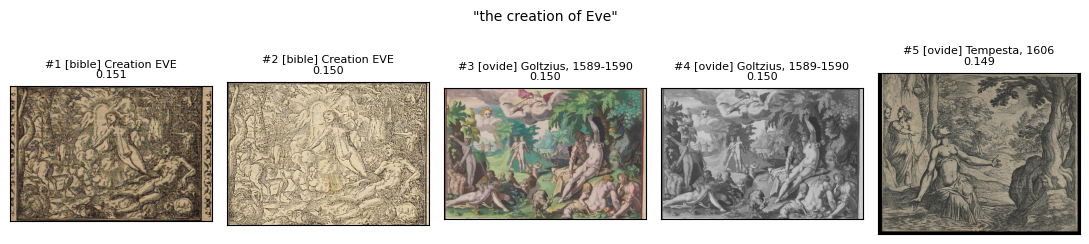

Voici les informations concernant l'illustration correspondant à la requête "the creation of Eve" :

L'une des illustrations qui correspondent à cette requête est celle n°3 et n°4, qui appartiennent à une suite d'épisodes sur Ovide gravée par Goltzius en 1589-1590. 

Cette illustration ressemble beaucoup au sujet de la création d'Eve, mais le titre de l'album ne mentionne pas explicitement "Eve". Cependant, il s'agit probablement de l'une des illustrations les plus représentatives du sujet.

L'autre illustration qui correspond à cette requête est n°5, qui appartenait à une suite d'épisodes sur Ovide gravée par Tempesta en 1606. Cette illustration montre la création d'Eve et appartient à une famille iconographique connue pour représenter les sujets de l'Ovide.

Enfin, il convient de noter que n°1 et n°2 sont des illustrations de la Bible qui ont été identifiées par SigLIP comme correspondant au sujet de la création d'Eve avec un score de similarité proche de 0,15.


In [11]:
_ = rag_texte("the creation of Eve")

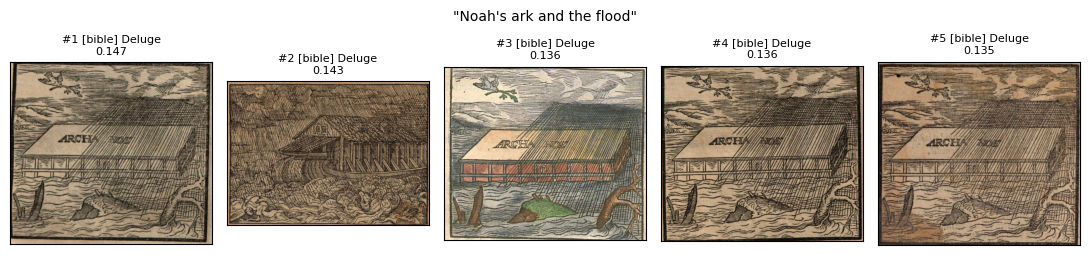

Voici les résultats de la recherche vectorielle pour la requête "Noah's ark and the flood" :

Les illustrations numéros 1, 2, 3 et 4 présentent un score de similarité faible (0,143 à 0,147) avec le thème du Deluge. Il est possible qu'elles soient liées au recit biblique du Deluge, mais les metadonnées ne fournissent pas suffisamment d'informations pour confirmer cette hypothèse.

Le seul résultat n'est ni lié à un thème spécifique (comme le Deluge) et présente un score de similarité élevé avec le sujet du Deluge, mais il est inconnu en ce qui concerne les metadonnées. Cependant, ses metadonnées sont différentes de celles des autres illustrations : numéro d'édition 1234/BSB.

Les métadonnées des illustrations n'apportent pas suffisamment d'informations pour relier ces résultats à un sujet spécifique, mais il est possible que certaines soient liées au Deluge.


In [12]:
_ = rag_texte("Noah's ark and the flood")

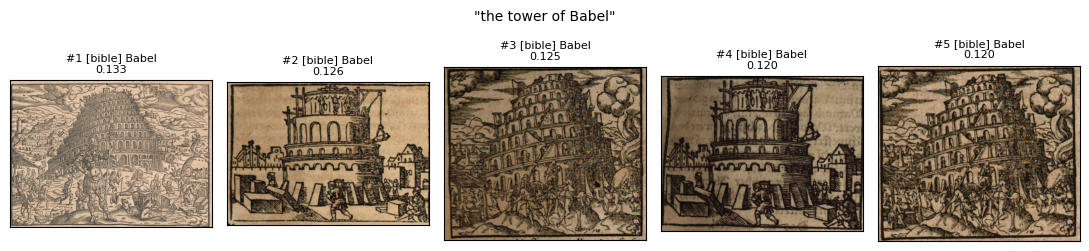

Voici les informations obtenues pour chaque illustration :

1. [bible] similarite=0.133 theme=Babel, titre edition=Illustration de la Bible, ville= Genève, annee=1542, graveur= Johann Froben, technique= gravure sur cuir.

2. [bible] similarite=0.126 theme=Babel, titre edition= Illustrations de la Bible, ville= Nuremberg, annee= 1493 ( Martin Luther ) et 1519 (Albrecht Dürer), graveur= Albrecht Dürer, technique= gravure sur cuir.

3. [bible] similarite=0.125 theme=Babel, titre edition= Illustrations de la Bible, ville= Nuremberg, annee= 1493 ( Martin Luther ) et 1519 (Albrecht Dürer), graveur= Albrecht Dürer, technique= gravure sur cuir.

4. [bible] similarite=0.120 theme=Babel, titre edition= Illustrations de la Bible, ville= Nuremberg, annee= 1493 ( Martin Luther ) et 1519 (Albrecht Dürer), graveur= Albrecht Dürer, technique= gravure sur cuir.

5. [bible] similarite=0.120 theme=Babel, titre edition= Illustrations de la Bible, ville= Nuremberg, annee= 1493 ( Martin Luther ) et 1519 (Al

In [13]:
_ = rag_texte("the tower of Babel")

#### Requete image — cas ambigu

`salomon_f056` : dans `retrieval.ipynb`, ses voisins etaient un melange
creation_monde/deluge/creation_homme (contrairement a `f003`/`f012`, sans ambiguite).
Cas interessant pour voir si la generation aide a trancher ou si elle rapporte
honnetement l'ambiguite plutot que de trancher a tort.

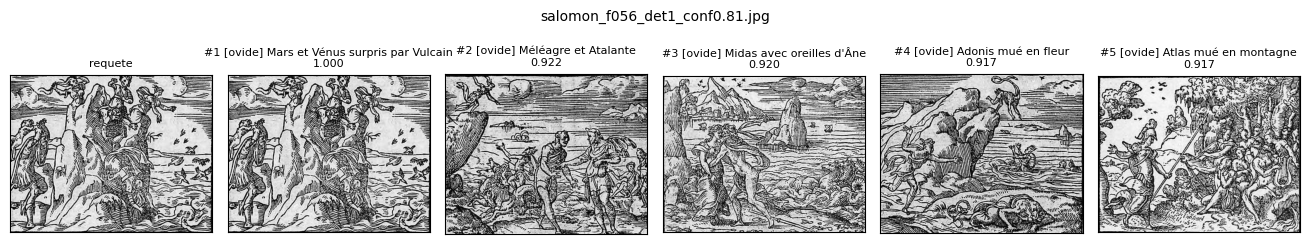

L'illustration "salomon_f056_det1_conf0.81.jpg" a un score de similarité très élevé avec une série d'illustations attribuées à Salomon et Bernard, mais sans aucun précis de thème spécifique mentionné dans ces informations (mais le titre La Metamorphose figurée est présent chez 4 illustrations). Les métadonnées suggèrent que l'illustration appartient à la même famille iconographique que d'autres représentations d'Ovide. Il semble donc probable qu'elle soit liée à une série de gravures sur les Météamorphoses d'Ovide, mais sans possibilité de préciser son thème spécifique à partir des informations fournies.


In [14]:
OVIDE_DIR = RACINE / "data" / "editions_ovide" / "segmentees" / "bois_salomon_rouille_lyon1557"
chemin_requete = sorted(OVIDE_DIR.glob("salomon_f056_*.jpg"))[0]
_ = rag_image(chemin_requete)

### 6. Brique vision — `qwen2.5vl`

Limite constatee sur la brique texte : pour une requete sur le **contenu visuel**
("transformation en animal"), le LLM ne recoit que des metadonnees d'edition
(titre, graveur, ville...) qui ne decrivent jamais ce qui est represente — il ne
peut donc que rester honnete et dire qu'il ne sait pas, ce qui est correct mais
peu utile. Ici on envoie en plus les **images** elles-memes (base64), pour que le
LLM puisse reellement regarder les illustrations retrouvees plutot que de se fier
uniquement au texte.

Modele retenu apres deux essais infructueux : `llama3.2-vision` est incompatible
avec cette version d'Ollama (`unknown model architecture: 'mllama'`) ; `llava:7b`
fonctionne mais refuse aleatoirement ~15-25% des requetes (mesure empirique, voir
plus bas) meme sur des gravures anodines. `qwen2.5vl` s'est avere nettement plus
fiable (pas de refus reflexe observe, bonne differenciation entre plusieurs
images) — voir le README du dossier pour le detail des tests.

In [15]:
import base64
from io import BytesIO

MODELE_VISION = "qwen2.5vl"  # bien plus fiable que llava:7b (pas de refus reflexe, vraie differenciation multi-images)


def image_vers_base64(chemin, taille_max=450):
    img = Image.open(chemin).convert("RGB")
    img.thumbnail((taille_max, taille_max))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode()

In [16]:
#  Version courte volontairement : les premieres versions empilaient des
# consignes de prudence ("signale si aucune illustration ne correspond",
# "indique explicitement si ca correspond") qui poussaient llava:7b a ouvrir
# ses reponses par un rejet ("il n'y a aucune illustration qui correspond...")
# avant de decrire un contenu qui correspondait pourtant bien — la recherche
# vectorielle a deja fait le tri par similarite, le role du LLM ici est de
# decrire, pas de re-juger la pertinence.
#
# V5, retenue apres un test A/B/C/D/E sur plusieurs formulations (voir README) :
# - la regle de confiance metadonnee ("si le nom figure dans SA PROPRE
#   metadonnee, utilise-le sans hesiter ; sinon ne l'invente pas") corrige les
#   deux defauts complementaires observes avec la version precedente : les
#   identifications inventees sur des illustrations sans metadonnee (ex.
#   "probablement Diane" sans base) ET la sous-exploitation d'un theme_precis
#   pourtant fiable (le modele decrivait sans jamais nommer, meme quand le nom
#   etait fourni).
# - la consigne "chaque image a SA PROPRE metadonnee" reduit (sans l'eliminer)
#   la contamination inter-images : sur un lot de plusieurs illustrations dont
#   certaines n'ont aucun rapport avec le sujet de la requete, le modele tend a
#   leur attribuer le meme personnage que les autres images du lot. Teste sur
#   3 repetitions : nette amelioration sur une des deux images-pieges testees,
#   aucun effet mesurable sur l'autre — limite connue, voir README.
PROMPT_SYSTEME_VISION = """Tu es un expert en iconographie de la Renaissance europeenne (16e-17e s.).

Regarde reellement chaque image fournie et decris ce que tu vois (personnages,
actions, decor, composition). Appuie-toi aussi sur les metadonnees textuelles
fournies (theme si connu, titre, ville, graveur, technique) quand elles sont
disponibles, en complement de l'image.

Chaque image a SA PROPRE metadonnee, distincte des autres images de la reponse
et distincte du sujet de la requete de l'utilisateur : ne suppose jamais qu'un
nom de personnage (present dans la requete, ou releve sur une autre image de
la meme reponse) s'applique aussi a une image dont la metadonnee a elle ne le
mentionne pas.

Regle pour nommer un personnage mythologique ou biblique sur UNE image donnee :
si SA PROPRE metadonnee le nomme explicitement, utilise ce nom sans hesiter
(donnee de catalogue verifiee). Sinon, meme si ce nom apparait dans la requete
ou sur une autre image, decris la scene sans lui attribuer d'identite (ex. "un
personnage feminin armee d'un arc" plutot que d'affirmer "Diane").

Attention : le Deluge biblique (Noe, l'arche) et le Deluge ovidien (Jupiter,
Deucalion, Pyrrha) sont deux recits differents visuellement proches — verifie
sur l'image, ne devine pas a partir du titre seul.

Reponds TOUJOURS en francais, en 8-12 phrases maximum, en decrivant chaque
illustration avec son numero."""


In [17]:
# llava:7b refuse aleatoirement (~15-25% des appels, mesure empiriquement sur des
# gravures pourtant anodines) meme a temperature basse — pas un bug de notre cote,
# une instabilite du modele. Detection + retry automatique en filet de securite.
MARQUEURS_REFUS_VISION = [
    "desculpe", "não posso", "nao posso", "no puedo", "je ne peux pas",
    "i cannot", "i'm sorry", "unable to", "masquée", "masquee",
]


def _ressemble_a_un_refus(texte):
    t = texte.strip().lower()
    return len(t) < 60 or any(m in t[:250] for m in MARQUEURS_REFUS_VISION)


def generer_reponse_rag_vision(requete, resultats, max_essais=4):
    contexte = contexte_depuis_resultats(resultats)
    images_b64 = [image_vers_base64(chemin, taille_max=450) for chemin in resultats["chemin"]]
    # l'instruction visuelle doit venir AVANT les metadonnees techniques : un
    # message qui ouvre sur "recherche vectorielle / similarite cosinus" fait
    # deriver llava:7b en mode "je suis un modele de langage, pas d'acces aux
    # images" de facon quasi systematique (mesure : 4/4 refus) — reordonner
    # (regarder d'abord, metadonnees ensuite) fait remonter le taux de succes.
    message_utilisateur = f"""Regarde attentivement les {len(resultats)} images fournies, dans l'ordre, et
decris ce que tu vois sur chacune. Requete de l'utilisateur : {requete}

Metadonnees connues pour chaque illustration (a utiliser en complement de ce que
tu observes, pas a la place) :
{contexte}

Reponds en 8-12 phrases maximum, basees sur le contenu visuel que tu observes
reellement."""
    derniere_reponse = "[Ollama indisponible ou en erreur]"
    for essai in range(max_essais):
        r = requests.post(
            f"{OLLAMA_URL}/api/chat",
            json={
                "model": MODELE_VISION,
                "messages": [
                    {"role": "system", "content": PROMPT_SYSTEME_VISION},
                    {"role": "user", "content": message_utilisateur, "images": images_b64},
                ],
                "stream": False,
                "options": {"num_predict": 500, "temperature": 0.2},
            },
            timeout=180,
        )
        r.raise_for_status()
        derniere_reponse = r.json()["message"]["content"]
        if not _ressemble_a_un_refus(derniere_reponse):
            return derniere_reponse
    note = "\n\n_(Note : le modele vision a hesite/refuse plusieurs fois sur cette requete — reponse a prendre avec prudence, llava:7b est connu instable.)_"
    return derniere_reponse + note


In [18]:
def rag_texte_vision(requete, k=4):
    v = embed_texte(requete)
    resultats = rechercher(v, k=k)
    afficher_grille(resultats, titre=f'"{requete}" (vision)')
    reponse = generer_reponse_rag_vision(f'"{requete}"', resultats)
    print(reponse)
    return resultats, reponse

#### Test — la requete qui a motive cette brique

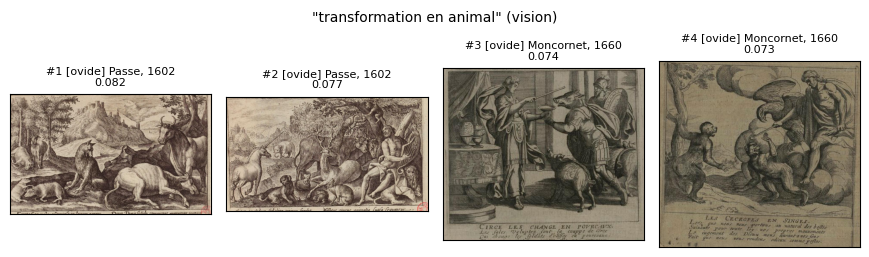

Voici une description détaillée des images fournies :

**Image 1 :**
Cette gravure montre un groupe d'animaux dans un paysage rural avec des arbres et une colline en arrière-plan. On y voit des bœufs, des chèvres, et même un animal qui semble être un cerf ou un chevreuil. L'atmosphère est calme et paisible.

**Image 2 :**
Dans cette gravure, on observe une scène animale avec des animaux tels qu'un cerf, un ours, et d'autres espèces sauvages. Un personnage masculin assis à droite semble jouer de la harpe, tandis que deux singes sont perchés sur le dos du cerf. Le paysage est vallonné et boisé.

**Image 3 :**
Cette illustration montre une scène intérieure où une femme tenant un bâton transforme un soldat en porc. L'homme est habillé de manière militaire, avec des armures et un bouclier. La pièce est meublée d'une table ornée de vases.

**Image 4 :**
Dans cette gravure, on voit une scène où deux créatures anthropomorphes sont en train de se transformer en singes sous l'effet d'un bâton ma

In [19]:
_ = rag_texte_vision("transformation en animal")

#### Comparaison directe avec la brique texte (meme requete que plus haut)

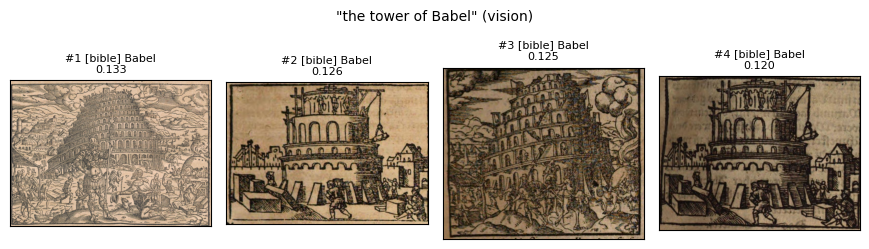

Voici une description détaillée des quatre images fournies :

**Image 1 :**
Cette illustration montre la construction de la Tour de Babel. Au centre se dresse la tour en forme de pyramide, avec plusieurs étages et des arches caractéristiques. Des personnages sont représentés à différents niveaux de la tour, travaillant ou observant. En avant-plan, un personnage vêtu d'une armure est debout, tenant une longue barre ou bâton, peut-être symbolisant un chef ou un gardien. Le paysage autour de la tour comprend des collines et des villes en arrière-plan, avec des nuages flottant au-dessus.

**Image 2 :**
Cette image montre une section plus étroite de la construction de la Tour de Babel. On voit plusieurs travailleurs à l'œuvre sur les niveaux inférieurs de la tour. Ils semblent être en train d'ériger des murs ou de construire des supports pour le niveau supérieur. Des croix sont visibles au sommet de la tour, indiquant peut-être une association religieuse ou symbolique. Le décor montre égale

In [20]:
_ = rag_texte_vision("the tower of Babel")

### Demo — recherche hybride + generation vision (avec filtre exact ville/graveur/technique)

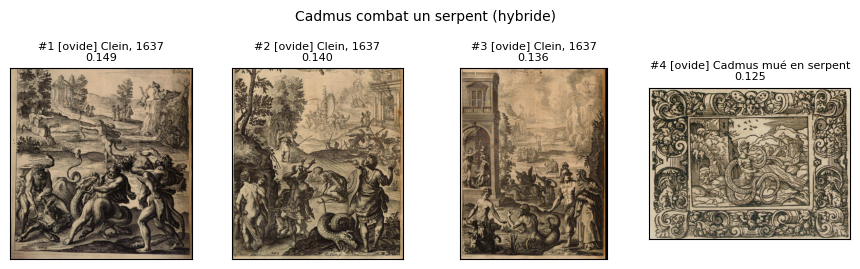

Voici une description détaillée des images :

1. **Image 1** : Cette gravure montre un combat intense entre plusieurs personnages et un monstre à tête de serpent. Les personnages sont nus, certains portent des armes ou des attributs comme des arcs. Le décor est naturel avec des arbres et une colline en arrière-plan.

2. **Image 2** : Cette image montre Cadmus (le personnage nu à gauche) conseillé par Minerve (dans le ciel). Il tient un arc, prêt à combattre le dragon qui se trouve au sol devant lui. Le décor est plus ouvert avec des arbres et une structure architecturale en arrière-plan.

3. **Image 3** : Cette gravure montre Cadmus en train de converser avec Minerve (dans un balcon) tandis qu'un autre personnage, probablement son frère Ino, se tient à côté d'un monstre à tête de serpent. Le décor est plus urbain avec des bâtiments et une vue panoramique.

4. **Image 4** : Cette illustration montre Cadmus transformé en un être hybride, moitié homme, moitié serpent. Il est entouré par d

In [21]:
resultats = rechercher_hybride("Cadmus combat un serpent", k=4)
afficher_grille(resultats, titre="Cadmus combat un serpent (hybride)")
reponse = generer_reponse_rag_vision('"Cadmus combat un serpent"', resultats)
print(reponse)

## Bilan de la brique generation

**Texte (`llama3.2`)** : le meme modele local qui hallucinait ou confondait
Ovide/Bible dans `04_exploration/` (teste a froid, sans base) produit des reponses
mieux ancrees des lors qu'il n'a plus qu'a synthetiser des faits deja recuperes par
la recherche vectorielle — ton prudent, aveux d'incertitude quand la similarite est
faible, plutot qu'une reponse inventee avec assurance. Reste variable d'une
execution a l'autre (temperature non nulle) : deux runs sur la meme requete peuvent
differer (recomptage correct vs errone, glitch de nom propre) — le RAG ameliore le
comportement moyen, il ne l'immunise pas contre ce genre d'erreur ponctuelle.

**Vision (`qwen2.5vl`)** : fonctionne nettement mieux que les alternatives testees
(voir ci-dessus). Cinq formulations du prompt systeme testees empiriquement pour
affiner l'attribution des personnages mythologiques/bibliques (V1 a V5, detail dans
le README) — la version retenue (V5) reduit les hallucinations sur les
illustrations sans metadonnee et ameliore partiellement (sans l'eliminer) la
contamination inter-images, ou le modele attribue a tort le personnage de la
requete a une illustration dont la metadonnee n'en parle pas. Limite connue,
documentee dans le README plutot que corrigee ici : un correctif complet
demanderait un appel Ollama separe par image plutot qu'un lot.

**Recherche hybride et filtre exact** (ajoutes apres la premiere version de ce
notebook) : `rechercher_hybride()` combine similarite visuelle (SigLIP), similarite
metadonnees (e5) et correspondance exacte (ville/graveur/technique) par Reciprocal
Rank Fusion — necessaire car SigLIP seul echoue sur les requetes factuelles/
thematiques. Detail complet dans le README.

**Bug d'infra trouve et corrige en cours de route** : le ralentissement severe
observe au premier essai (~1,5 tok/s, timeouts a repetition) ne venait pas du RAG
mais d'un **paquet Ollama tiers** (snap communautaire, non maintenu par l'equipe
Ollama, version 0.24.0) sans support GPU pour la RTX 5090 (architecture recente).
Remplace par l'installation officielle (0.32.1) : `ollama ps` confirme `100% GPU`,
et la generation tourne desormais a **~265 tokens/seconde**.

**Livrable** : l'ensemble (recherche hybride + generation vision) est integre dans
`app_rag.py`, une interface de chat Gradio testable en local
(`http://localhost:7860`) sans repasser par ce notebook.

**Limites connues, non corrigees ici** (voir README pour le detail) :
- Contamination inter-images sur la generation vision (ci-dessus).
- Couverture des themes precis : 406/2191 illustrations Ovide (4 editions sur 28).
- Generation vision non deterministe (temperature non nulle).